# Introduction

This experiment interprets the selected Gradient Boosting model by examining feature importance to identify the agricultural and environmental variables that contributed most to Standard Yield predictions.

In [1]:
cd ..

/home/dataflix/Projects/maji-ndogo-yield-intelligence


## Import and Load model parameters

In [2]:
# This parameters were established after conducting 
# random search cross validation from gradient boosting experiment
# Its available in notebooks/07_gradient_boosting.ipynb

gradient_params = {
    "n_estimators": 661,
    "learning_rate": 0.168307,
    "max_depth": 4,
    "min_samples_split": 18,
    "min_samples_leaf": 14,
    "subsample": 0.865009
}

In [3]:
from model_pipelines.ensemble_models import EnsembleStacking
ensemble = EnsembleStacking()
ensemble.prepare_data()
ensemble.feature_transfromer()
gradient_pipeline = ensemble.gradient_boosting_pipeline(**gradient_params)

2026-08-25 23:19:47 | src.data_ingestion | INFO | Starting data ingestion
2026-08-25 23:19:47 | src.preprocessing | INFO | Model preprocessor is initialized
2026-08-25 23:19:47 | model_pipelines.ensemble_models | INFO | RandomForestRegressor is initialized
2026-08-25 23:19:47 | src.field_data_processor | INFO | FieldDataProcessor is initialized
2026-08-25 23:19:47 | src.data_ingestion | INFO | Successfully connected to sqlite:///data/Maji_Ndogo_farm_survey_small.db
2026-08-25 23:19:47 | src.data_ingestion | INFO | Query executed successfully. Rows: 5654
2026-08-25 23:19:47 | src.field_data_processor | INFO | SQL data is successfully loaded into the pandas DataFrame
2026-08-25 23:19:47 | src.field_data_processor | INFO | Swapped columns: Annual_yield with Crop_type
2026-08-25 23:19:47 | src.field_data_processor | INFO | Converted the negative elavtion values to absulte figures.
2026-08-25 23:19:47 | src.field_data_processor | INFO | Mispelled crop names and extra spaces were found and g

In [4]:
from src.preprocessing import ModelPreprocessors
mp = ModelPreprocessors()
mp.prepare_data()
mp.X_y_features
X_train, X_test, y_train, y_test = mp.X_y_train_test_split()

2026-08-25 23:19:48 | src.preprocessing | INFO | Model preprocessor is initialized
2026-08-25 23:19:48 | src.field_data_processor | INFO | FieldDataProcessor is initialized
2026-08-25 23:19:48 | src.data_ingestion | INFO | Successfully connected to sqlite:///data/Maji_Ndogo_farm_survey_small.db
2026-08-25 23:19:48 | src.data_ingestion | INFO | Query executed successfully. Rows: 5654
2026-08-25 23:19:48 | src.field_data_processor | INFO | SQL data is successfully loaded into the pandas DataFrame
2026-08-25 23:19:48 | src.field_data_processor | INFO | Swapped columns: Annual_yield with Crop_type
2026-08-25 23:19:48 | src.field_data_processor | INFO | Converted the negative elavtion values to absulte figures.
2026-08-25 23:19:48 | src.field_data_processor | INFO | Mispelled crop names and extra spaces were found and got fixed
2026-08-25 23:19:48 | src.data_ingestion | INFO | Attempting to read CSV from: https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_dat

## Fit the Gradient Boost Regressor model

In [5]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [6]:
def gradient_boost_model(X_train, X_test, y_train) -> Pipeline | np.ndarray:
    gradient_model = gradient_pipeline.fit(X_train, y_train)
    y_pred = gradient_model.predict(X_test)
    return gradient_model, y_pred

gradient_model, y_pred = gradient_boost_model(X_train, X_test, y_train)


## Extract feature importance

In [7]:
def extract_feature_importance(gradient_model):
    transformer = gradient_model.named_steps["transformer"]
    model = gradient_model.named_steps["model"]
    feature_names = transformer.get_feature_names_out()

    feature_importance = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    })

    return feature_importance.sort_values("importance", ascending=False)


feature_importance = extract_feature_importance(gradient_model)
display(feature_importance)

,feature,importance
4,num__Rainfall,1.935616e-01
29,cat__Crop_type_tea,1.824106e-01
9,num__pH,1.136896e-01
1,num__Latitude,1.097551e-01
10,num__Pollution_level,9.257240e-02
0,num__Elevation,5.963469e-02
28,cat__Crop_type_rice,4.365296e-02
25,cat__Crop_type_coffee,3.985906e-02
17,cat__Soil_type_Loamy,3.832556e-02
27,cat__Crop_type_potato,2.875624e-02


In [ ]:
def prepare_feature_importance(feature_importance: pd.DataFrame) -> pd.DataFrame:

    feature_importance["feature_name"] = (
        feature_importance["feature"]
        .str.replace("num__", "", regex=False)
        .str.replace("cat__", "", regex=False)
        .str.replace("Crop_type_", "Crop: ", regex=False)
        .str.replace("Soil_type_", "Soil: ", regex=False)
        .str.replace("Location_", "Location: ", regex=False)
        .str.replace("_", " ", regex=False)
        .str.title()
        .str.replace("Ph", "pH", regex=False)
    )

    feature_importance = (feature_importance.sort_values("importance", ascending=False).reset_index(drop=True))

    feature_importance.index += 1
    feature_importance.index.name = "Rank"
    feature_importance = feature_importance[["feature_name", "importance"]]
    feature_importance["importance"] = feature_importance["importance"].apply(lambda x: f"{x:.4f}")

    return feature_importance

feature_importance = prepare_feature_importance(feature_importance)
display(feature_importance.head(10))

,feature_name,importance
Rank,,
1,Rainfall,0.1936
2,Crop: Tea,0.1824
3,pH,0.1137
4,Latitude,0.1098
5,Pollution Level,0.0926
6,Elevation,0.0596
7,Crop: Rice,0.0437
8,Crop: Coffee,0.0399
9,Soil: Loamy,0.0383


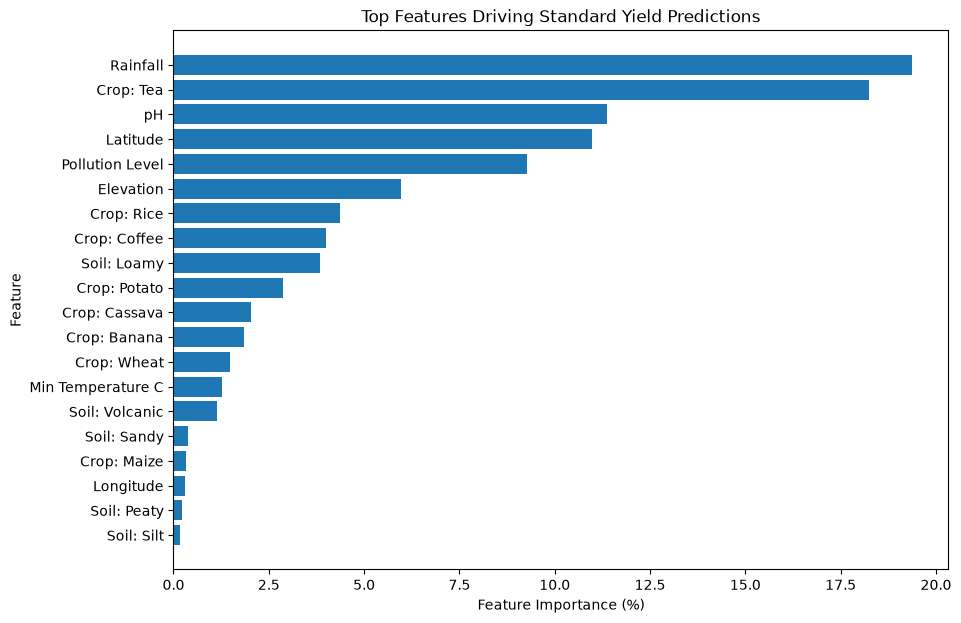

In [23]:
top_features = (
    feature_importance.assign(importance=pd.to_numeric(feature_importance["importance"]))
    .head(20)
    .sort_values("importance", ascending=True)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 7))

plt.barh(top_features["feature_name"],top_features["importance"] * 100)
plt.xlabel("Feature Importance (%)")
plt.ylabel("Feature")
plt.title("Top Features Driving Standard Yield Predictions")

plt.show()   

### Insight

The feature-importance analysis shows that **Rainfall** was the most influential predictor of Standard Yield, followed by **Tea crop type, pH, Latitude, Pollution level, and Elevation**. These findings largely align with patterns identified during EDA, indicating that the Gradient Boosting model captured important environmental, geographical, and crop-related relationships. However, feature importance reflects the model's reliance on each feature and **does not establish causality or the direction of the relationship**. Overall, the results provide a clear explanation of the key factors contributing to the model's predictions and reinforce the suitability of Gradient Boosting for this nonlinear yield-prediction problem.
